# Student Pass/Fail – EDA & Feature Engineering


## Problem Statement

Analyze student academic data to understand which factors are associated with passing and prepare the dataset for basic Machine Learning.




## Objectives
- Explore the student academic dataset
- Identify missing values and duplicate records
- Detect invalid values and outliers
- Analyze relationships between academic factors and pass/fail status
- Clean the dataset
- Create meaningful features
- Separate features (X) and target (y)

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Dataset

df = pd.read_csv("01_student_pass_fail.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display First 5 Rows

df.head()

,study_hours,attendance,assignments_completed,previous_score,pass
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,NaN,56.0,1
4,1.1,55.9,2.0,82.0,0


In [4]:
# Dataset Shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1020
Columns: 5


In [5]:
# Column Names

print(df.columns.tolist())

['study_hours', 'attendance', 'assignments_completed', 'previous_score', 'pass']


In [6]:
# Data Types and Missing Values

print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
study_hours              float64
attendance               float64
assignments_completed    float64
previous_score           float64
pass                       int64
dtype: object

Missing Values:
study_hours              10
attendance               10
assignments_completed    10
previous_score           11
pass                      0
dtype: int64


In [7]:
# Check Duplicate Records

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 20


In [8]:
# Statistical Summary

df.describe()

,study_hours,attendance,assignments_completed,previous_score,pass
count,1010.000000,1010.000000,1010.000000,1009.000000,1020.000000
mean,5.438416,74.219406,5.085149,63.114965,0.797059
std,2.627462,14.788949,3.215528,19.981506,0.402386
min,-2.000000,50.100000,-3.000000,30.000000,0.000000
25%,3.200000,60.900000,2.000000,46.000000,1.000000
50%,5.500000,74.000000,5.000000,63.000000,1.000000
75%,7.600000,86.800000,8.000000,80.000000,1.000000
max,10.000000,120.000000,10.000000,150.000000,1.000000


In [9]:
# Check Invalid Values

print("Negative Study Hours:")
print(df[df["study_hours"] < 0])

print("\nAttendance Above 100:")
print(df[df["attendance"] > 100])

print("\nNegative Assignments:")
print(df[df["assignments_completed"] < 0])

print("\nPrevious Score Above 100:")
print(df[df["previous_score"] > 100])

Negative Study Hours:
     study_hours  attendance  assignments_completed  previous_score  pass
27          -2.0        65.1                    5.0            49.0     0
111         -2.0        84.1                    3.0            42.0     1
655         -2.0        55.0                    4.0            38.0     0
681         -2.0        69.1                    9.0            71.0     1
929         -2.0        85.0                    3.0            82.0     1

Attendance Above 100:
      study_hours  attendance  assignments_completed  previous_score  pass
784           1.8       120.0                    7.0            30.0     0
825           6.7       120.0                    0.0            34.0     1
855           3.5       120.0                    8.0            73.0     1
901           8.9       120.0                    4.0            35.0     1
1001          5.6       120.0                    8.0            48.0     1

Negative Assignments:
      study_hours  attendance  assignm

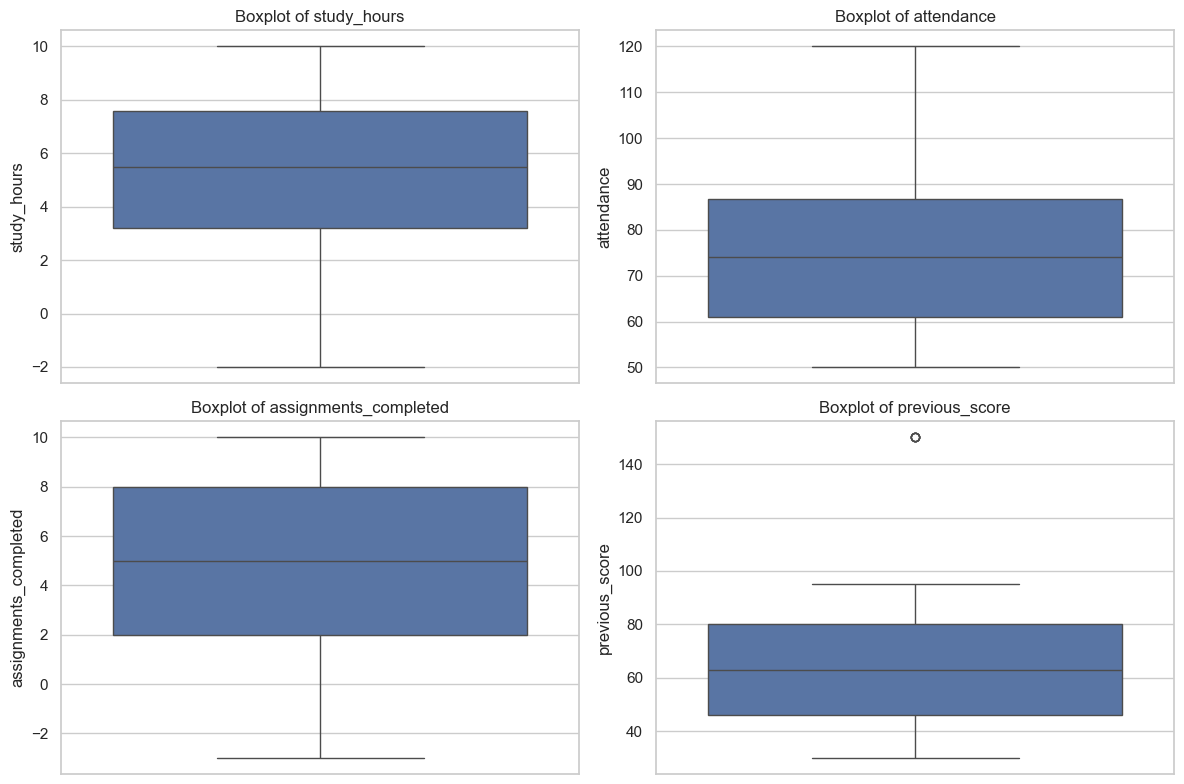

In [10]:
# Check Outliers Using Boxplots

numeric_columns = [
    "study_hours",
    "attendance",
    "assignments_completed",
    "previous_score"
]

plt.figure(figsize=(12, 8))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

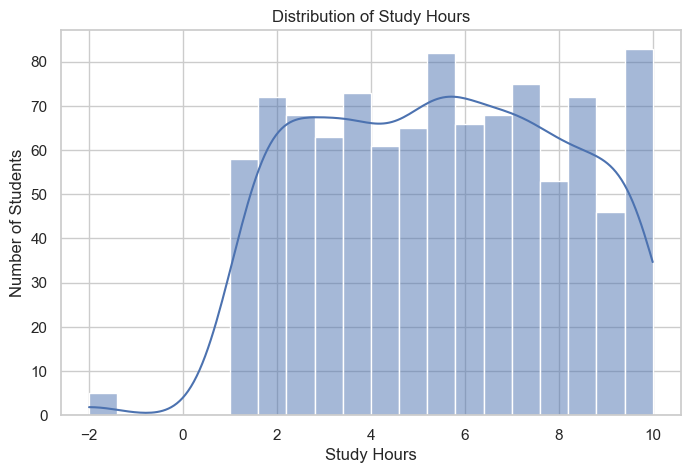

In [11]:
# Study Hours Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["study_hours"], bins=20, kde=True)
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.show()

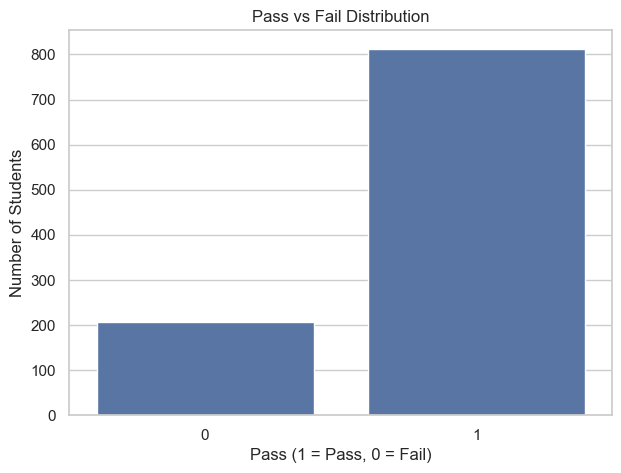

In [12]:
# Pass vs Fail Distribution

plt.figure(figsize=(7, 5))
sns.countplot(x="pass", data=df)
plt.title("Pass vs Fail Distribution")
plt.xlabel("Pass (1 = Pass, 0 = Fail)")
plt.ylabel("Number of Students")
plt.show()

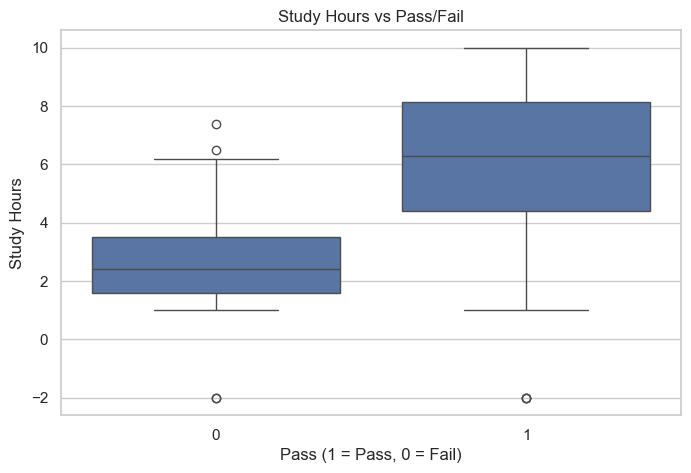

In [13]:
# Study Hours vs Pass/Fail

plt.figure(figsize=(8, 5))
sns.boxplot(x="pass", y="study_hours", data=df)
plt.title("Study Hours vs Pass/Fail")
plt.xlabel("Pass (1 = Pass, 0 = Fail)")
plt.ylabel("Study Hours")
plt.show()

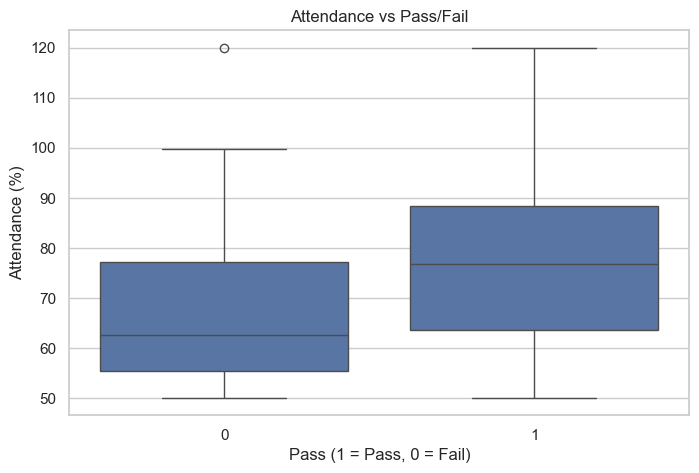

In [14]:
# Attendance vs Pass/Fail

plt.figure(figsize=(8, 5))
sns.boxplot(x="pass", y="attendance", data=df)
plt.title("Attendance vs Pass/Fail")
plt.xlabel("Pass (1 = Pass, 0 = Fail)")
plt.ylabel("Attendance (%)")
plt.show()

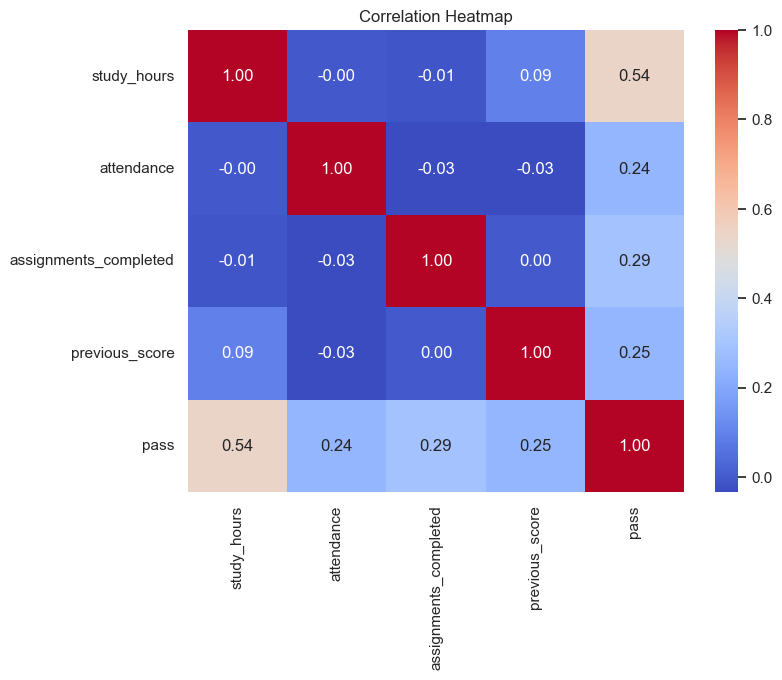

In [15]:
# Correlation Matrix / Heatmap

plt.figure(figsize=(8, 6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Create a Clean Copy

df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Fix invalid values by converting them to NaN
df_clean.loc[df_clean["study_hours"] < 0, "study_hours"] = np.nan
df_clean.loc[df_clean["attendance"] > 100, "attendance"] = np.nan
df_clean.loc[df_clean["assignments_completed"] < 0, "assignments_completed"] = np.nan
df_clean.loc[df_clean["previous_score"] > 100, "previous_score"] = np.nan

# Fill missing numerical values with median
numeric_columns = [
    "study_hours",
    "attendance",
    "assignments_completed",
    "previous_score"
]

for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Data cleaning completed!")

Data cleaning completed!


In [17]:
# Re-check Cleaned Dataset

print("Shape after cleaning:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

df_clean.head()

Shape after cleaning: (1000, 5)

Missing values:
study_hours              0
attendance               0
assignments_completed    0
previous_score           0
pass                     0
dtype: int64

Duplicate rows:
0


,study_hours,attendance,assignments_completed,previous_score,pass
0,6.3,84.1,0.0,83.0,1
1,2.6,50.3,4.0,76.0,0
2,8.8,65.3,7.0,92.0,1
3,6.8,99.3,5.0,56.0,1
4,1.1,55.9,2.0,82.0,0


In [18]:
# Feature 1: Study Attendance Score

df_clean["study_attendance_score"] = (
    df_clean["study_hours"] * df_clean["attendance"] / 100
)

In [19]:
# Feature 2: Academic Performance Score

df_clean["academic_performance_score"] = (
    df_clean["previous_score"] * 0.7
    + df_clean["assignments_completed"] * 3
)

In [20]:
# Display New Features

df_clean[
    [
        "study_hours",
        "attendance",
        "assignments_completed",
        "previous_score",
        "study_attendance_score",
        "academic_performance_score"
    ]
].head()

,study_hours,attendance,assignments_completed,previous_score,study_attendance_score,academic_performance_score
0,6.3,84.1,0.0,83.0,5.2983,58.1
1,2.6,50.3,4.0,76.0,1.3078,65.2
2,8.8,65.3,7.0,92.0,5.7464,85.4
3,6.8,99.3,5.0,56.0,6.7524,54.2
4,1.1,55.9,2.0,82.0,0.6149,63.4


In [21]:
# Final Dataset Overview

print("Final Dataset Shape:", df_clean.shape)

print("\nFinal Columns:")
print(df_clean.columns.tolist())

df_clean.head()

Final Dataset Shape: (1000, 7)

Final Columns:
['study_hours', 'attendance', 'assignments_completed', 'previous_score', 'pass', 'study_attendance_score', 'academic_performance_score']


,study_hours,attendance,assignments_completed,previous_score,pass,study_attendance_score,academic_performance_score
0,6.3,84.1,0.0,83.0,1,5.2983,58.1
1,2.6,50.3,4.0,76.0,0,1.3078,65.2
2,8.8,65.3,7.0,92.0,1,5.7464,85.4
3,6.8,99.3,5.0,56.0,1,6.7524,54.2
4,1.1,55.9,2.0,82.0,0,0.6149,63.4


In [22]:
# Separate Features (X) and Target (y)

X = df_clean.drop("pass", axis=1)
y = df_clean["pass"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (1000, 6)
y shape: (1000,)

Features:
['study_hours', 'attendance', 'assignments_completed', 'previous_score', 'study_attendance_score', 'academic_performance_score']

Target:
pass
